In [2]:
# 02 - LIMPIEZA Y PROCESAMIENTO DE DATOS
# Objetivo: Cargar, limpiar y preparar datos para análisis

# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas")
print(f"📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Bibliotecas importadas
📅 Fecha: 2026-02-28 16:27:10


In [3]:
# Cargar todos los archivos CSV
print("📂 Cargando datos de data/raw/...\n")

data_files = {
    'fertility': None,
    'gdp': None,
    'unemployment': None,
    'education': None,
    'labor_force': None,
    'urbanization': None
}

# Buscar y cargar archivos
raw_path = '../data/raw/'
for filename in os.listdir(raw_path):
    if filename.endswith('.csv'):
        if 'fertility' in filename:
            data_files['fertility'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Fertilidad: {data_files['fertility'].shape}")
        elif 'gdp' in filename:
            data_files['gdp'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ PIB: {data_files['gdp'].shape}")
        elif 'unemployment' in filename:
            data_files['unemployment'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Desempleo: {data_files['unemployment'].shape}")
        elif 'education' in filename:
            data_files['education'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Educación: {data_files['education'].shape}")
        elif 'labor' in filename:
            data_files['labor_force'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Fuerza laboral: {data_files['labor_force'].shape}")
        elif 'urbanization' in filename:
            data_files['urbanization'] = pd.read_csv(raw_path + filename, index_col=0)
            print(f"✅ Urbanización: {data_files['urbanization'].shape}")

print(f"\n🎉 {sum(1 for v in data_files.values() if v is not None)}/6 datasets cargados exitosamente")

📂 Cargando datos de data/raw/...

✅ Educación: (266, 24)
✅ Fuerza laboral: (266, 24)
✅ Fertilidad: (266, 24)
✅ PIB: (266, 24)
✅ Desempleo: (266, 24)
✅ Urbanización: (266, 24)

🎉 6/6 datasets cargados exitosamente


In [6]:
# Analizar valores faltantes en cada dataset
print("🔍 ANÁLISIS DE VALORES FALTANTES\n")
print("="*60)

for name, df in data_files.items():
    if df is not None:
        total_values = df.size
        missing_values = df.isna().sum().sum()
        missing_pct = (missing_values / total_values) * 100
        
        print(f"\n📊 {name.upper()}")
        print(f"   Dimensiones: {df.shape[0]} países × {df.shape[1]} años")
        print(f"   Valores faltantes: {missing_values:,} de {total_values:,} ({missing_pct:.1f}%)")
        
        # Mostrar los primeros 3 países
        print(f"   Primeros 3 países: {df.index[0]}, {df.index[1]}, {df.index[2]}")

print("\n" + "="*60)
print("✅ Análisis completado")

🔍 ANÁLISIS DE VALORES FALTANTES


📊 FERTILITY
   Dimensiones: 266 países × 24 años
   Valores faltantes: 24 de 6,384 (0.4%)
   Primeros 3 países: ABW, AFE, AFG

📊 GDP
   Dimensiones: 266 países × 24 años
   Valores faltantes: 191 de 6,384 (3.0%)
   Primeros 3 países: ABW, AFE, AFG

📊 UNEMPLOYMENT
   Dimensiones: 266 países × 24 años
   Valores faltantes: 748 de 6,384 (11.7%)
   Primeros 3 países: ABW, AFE, AFG

📊 EDUCATION
   Dimensiones: 266 países × 24 años
   Valores faltantes: 1,856 de 6,384 (29.1%)
   Primeros 3 países: ABW, AFE, AFG

📊 LABOR_FORCE
   Dimensiones: 266 países × 24 años
   Valores faltantes: 748 de 6,384 (11.7%)
   Primeros 3 países: ABW, AFE, AFG

📊 URBANIZATION
   Dimensiones: 266 países × 24 años
   Valores faltantes: 24 de 6,384 (0.4%)
   Primeros 3 países: ABW, AFE, AFG

✅ Análisis completado


In [7]:
# Ver ejemplo de datos de FERTILIDAD
print("🔍 EJEMPLO DE DATOS - FERTILIDAD\n")
print(data_files['fertility'].head(10))
print(f"\nPaíses totales: {len(data_files['fertility'])}")

🔍 EJEMPLO DE DATOS - FERTILIDAD

             2000      2001      2002      2003      2004      2005      2006  \
economy                                                                         
ABW      1.845000  1.813000  1.800000  1.808000  1.819000  1.844000  1.862000   
AFE      5.549893  5.501766  5.449696  5.407328  5.381308  5.350399  5.305920   
AFG      7.566000  7.453000  7.320000  7.174000  7.018000  6.858000  6.686000   
AFW      6.022143  5.990074  5.956202  5.923573  5.895514  5.871770  5.846028   
AGO      6.639000  6.601000  6.567000  6.533000  6.499000  6.461000  6.419000   
ALB      2.217000  2.141000  2.002000  2.006000  1.889000  1.787000  1.686000   
AND      1.273000  1.305000  1.265000  1.180000  1.229000  1.224000  1.234000   
ARB      3.934749  3.858450  3.781001  3.727254  3.679651  3.643336  3.619228   
ARE      2.733000  2.622000  2.541000  2.491000  2.385000  2.232000  1.958000   
ARG      2.591000  2.531000  2.493000  2.451000  2.430000  2.426000  2.40000

In [8]:
# LIMPIEZA Y CREACIÓN DE DATASET MAESTRO
print("🧹 Limpiando datos y creando dataset maestro...\n")

# Convertir todo a formato long (país, año, valor)
dfs_long = []

for name, df in data_files.items():
    if df is not None:
        # Resetear índice para tener país como columna
        df_long = df.reset_index()
        df_long = df_long.melt(id_vars='economy', var_name='year', value_name=name)
        dfs_long.append(df_long)

# Combinar todos los datasets
master = dfs_long[0]
for df in dfs_long[1:]:
    master = master.merge(df, on=['economy', 'year'], how='outer')

# Convertir año a numérico
master['year'] = pd.to_numeric(master['year'])

# Renombrar columna economy a country
master = master.rename(columns={'economy': 'country'})

print(f"✅ Dataset maestro creado")
print(f"   Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas")
print(f"   Países únicos: {master['country'].nunique()}")
print(f"   Años: {master['year'].min()} - {master['year'].max()}")
print(f"\n📊 Columnas: {list(master.columns)}")
print(f"\n🔍 Primeras filas:")
master.head()

🧹 Limpiando datos y creando dataset maestro...

✅ Dataset maestro creado
   Dimensiones: 6384 filas × 8 columnas
   Países únicos: 266
   Años: 2000 - 2023

📊 Columnas: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization']

🔍 Primeras filas:


,country,year,fertility,gdp,unemployment,education,labor_force,urbanization
0,ABW,2000,1.845,20681.023027,NaN,NaN,NaN,65.354550
1,ABW,2001,1.813,20740.132583,NaN,98.647430,NaN,65.335114
2,ABW,2002,1.800,21307.248251,NaN,102.293442,NaN,65.282069
3,ABW,2003,1.808,21949.485996,NaN,104.977783,NaN,65.198292
4,ABW,2004,1.819,23700.631990,NaN,101.585007,NaN,65.088653


📈 Creando gráfico de tendencia global...



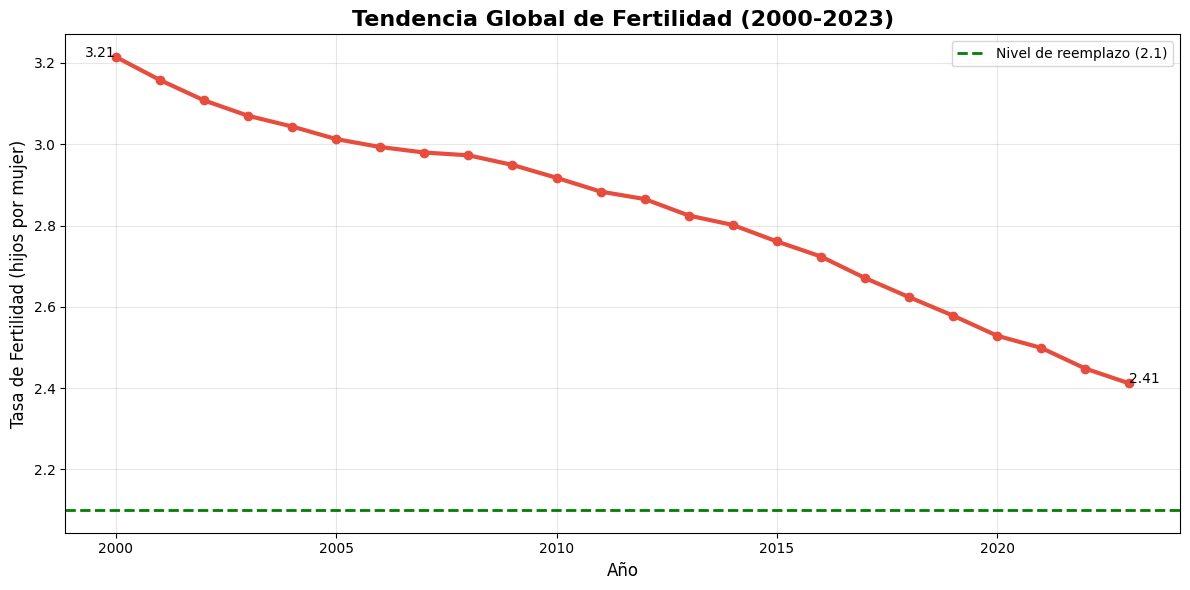

📊 Fertilidad promedio mundial:
   2000: 3.21 hijos por mujer
   2023: 2.41 hijos por mujer
   Cambio: -0.80 (-25.0%)


In [9]:
# VISUALIZACIÓN 1: Tendencia global de fertilidad
print("📈 Creando gráfico de tendencia global...\n")

# Calcular promedio mundial por año
global_trend = master.groupby('year')['fertility'].mean()

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.plot(global_trend.index, global_trend.values, linewidth=3, color='#e74c3c', marker='o')
plt.title('Tendencia Global de Fertilidad (2000-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Fertilidad (hijos por mujer)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=2.1, color='green', linestyle='--', linewidth=2, label='Nivel de reemplazo (2.1)')
plt.legend(fontsize=10)

# Añadir valores en puntos clave
plt.text(2000, global_trend[2000], f'{global_trend[2000]:.2f}', fontsize=10, ha='right')
plt.text(2023, global_trend[2023], f'{global_trend[2023]:.2f}', fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print(f"📊 Fertilidad promedio mundial:")
print(f"   2000: {global_trend[2000]:.2f} hijos por mujer")
print(f"   2023: {global_trend[2023]:.2f} hijos por mujer")
print(f"   Cambio: {global_trend[2023] - global_trend[2000]:.2f} ({(global_trend[2023] - global_trend[2000])/global_trend[2000]*100:.1f}%)")

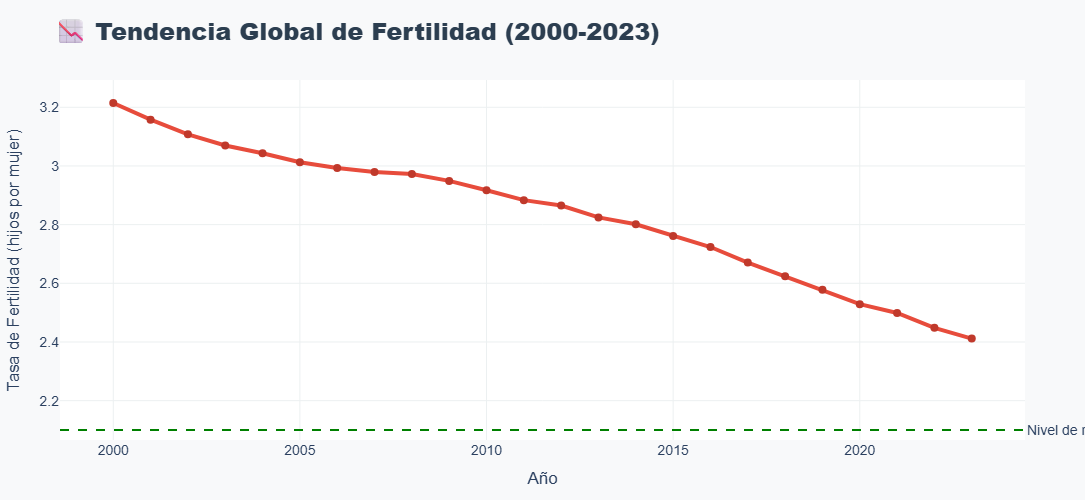


📊 INSIGHT CLAVE:
   La fertilidad global cayó de 3.21 a 2.41
   Esto es una caída del 25.0% en 23 años
   ¡Estamos -0.31 puntos por DEBAJO del nivel de reemplazo!


In [10]:
# VISUALIZACIÓN MEJORADA - Tendencia global PROFESIONAL
import plotly.graph_objects as go

# Calcular tendencia
global_trend = master.groupby('year')['fertility'].mean()

# Crear gráfico interactivo con Plotly
fig = go.Figure()

# Línea principal
fig.add_trace(go.Scatter(
    x=global_trend.index,
    y=global_trend.values,
    mode='lines+markers',
    name='Fertilidad Global',
    line=dict(color='#e74c3c', width=4),
    marker=dict(size=8, color='#c0392b'),
    hovertemplate='<b>%{x}</b><br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de reemplazo
fig.add_hline(
    y=2.1, 
    line_dash="dash", 
    line_color="green",
    annotation_text="Nivel de reemplazo (2.1)",
    annotation_position="right"
)

# Diseño profesional
fig.update_layout(
    title={
        'text': '📉 Tendencia Global de Fertilidad (2000-2023)',
        'font': {'size': 24, 'color': '#2c3e50', 'family': 'Arial Black'}
    },
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad (hijos por mujer)',
    font=dict(size=14, family='Arial'),
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='#f8f9fa',
    height=500,
    margin=dict(l=60, r=60, t=80, b=60)
)

# Grid sutil
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Stats
cambio_absoluto = global_trend[2023] - global_trend[2000]
cambio_porcentual = (cambio_absoluto / global_trend[2000]) * 100

print(f"\n📊 INSIGHT CLAVE:")
print(f"   La fertilidad global cayó de {global_trend[2000]:.2f} a {global_trend[2023]:.2f}")
print(f"   Esto es una caída del {abs(cambio_porcentual):.1f}% en 23 años")
print(f"   ¡Estamos {2.1 - global_trend[2023]:.2f} puntos por DEBAJO del nivel de reemplazo!")

🇭🇺 Analizando el caso de Hungría...



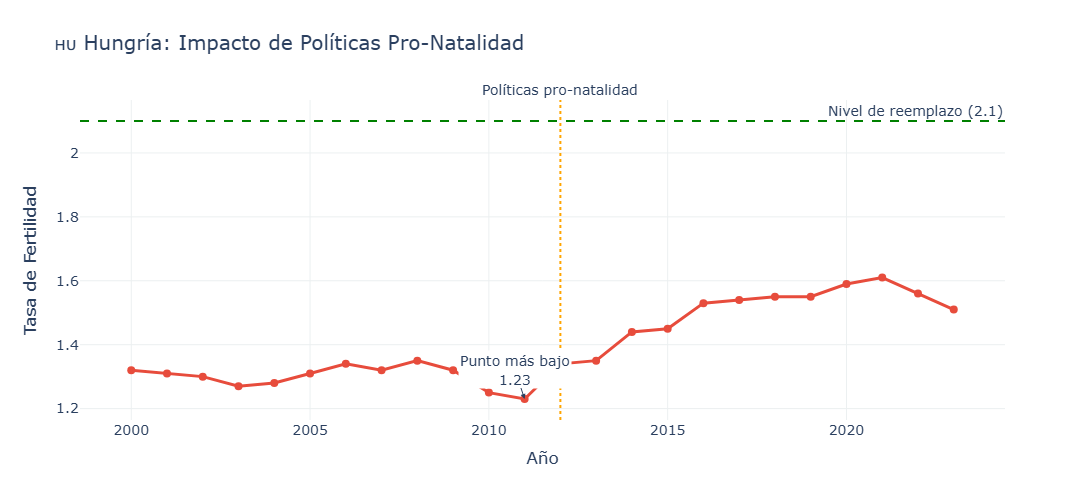

📉 Punto más bajo: 1.23 en 2011
📈 Valor en 2023: 1.51
🔄 Recuperación desde el mínimo: 0.28 puntos
⚠️  Pero aún 0.59 puntos por debajo del reemplazo


In [12]:
# VISUALIZACIÓN: Caso Hungría - Políticas pro-natalidad
print("🇭🇺 Analizando el caso de Hungría...\n")

# Filtrar datos de Hungría
hungary = master[master['country'] == 'HUN'].sort_values('year')

# Crear gráfico interactivo
fig = go.Figure()

# Línea de fertilidad
fig.add_trace(go.Scatter(
    x=hungary['year'],
    y=hungary['fertility'],
    mode='lines+markers',
    name='Hungría',
    line=dict(color='#e74c3c', width=3),
    marker=dict(size=8),
    hovertemplate='<b>%{x}</b><br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Nivel de reemplazo
fig.add_hline(y=2.1, line_dash="dash", line_color="green", 
              annotation_text="Nivel de reemplazo (2.1)")

# Marcar el punto de cambio de política (2012)
fig.add_vline(x=2012, line_dash="dot", line_color="orange",
              annotation_text="Políticas pro-natalidad", 
              annotation_position="top")

# Añadir anotaciones
fig.add_annotation(x=2011, y=1.23, text="Punto más bajo<br>1.23",
                   showarrow=True, arrowhead=2, bgcolor="white")

fig.update_layout(
    title='🇭🇺 Hungría: Impacto de Políticas Pro-Natalidad',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    font=dict(size=14),
    hovermode='x unified',
    plot_bgcolor='white',
    height=500
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Análisis
min_year = hungary[hungary['fertility'] == hungary['fertility'].min()]['year'].values[0]
min_val = hungary['fertility'].min()
val_2023 = hungary[hungary['year'] == 2023]['fertility'].values[0]

print(f"📉 Punto más bajo: {min_val:.2f} en {min_year}")
print(f"📈 Valor en 2023: {val_2023:.2f}")
print(f"🔄 Recuperación desde el mínimo: {val_2023 - min_val:.2f} puntos")
print(f"⚠️  Pero aún {2.1 - val_2023:.2f} puntos por debajo del reemplazo")

💰 Analizando relación entre PIB y Fertilidad...



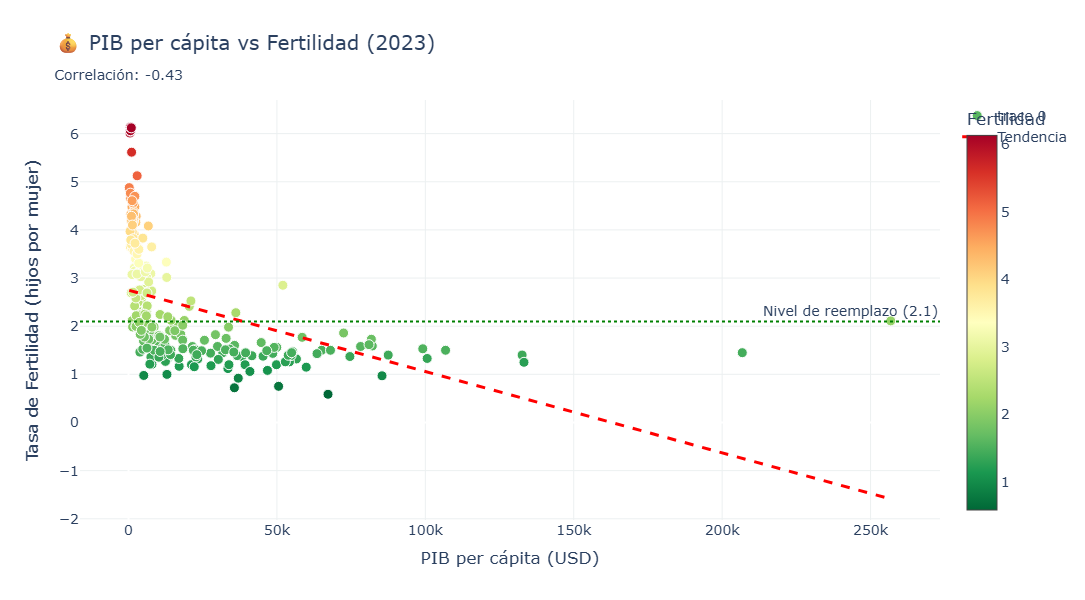

📊 CORRELACIÓN: -0.433
   ✅ Correlación NEGATIVA MODERADA

💎 TOP 5 PAÍSES MÁS RICOS:
   MCO: $256,800 → 2.11 hijos
   LIE: $206,781 → 1.45 hijos
   LUX: $133,231 → 1.25 hijos
   BMU: $132,604 → 1.40 hijos
   IRL: $106,819 → 1.50 hijos

👶 TOP 5 MAYOR FERTILIDAD:
   SOM: 6.13 hijos → $597
   TCD: 6.12 hijos → $949
   NER: 6.06 hijos → $638
   COD: 6.05 hijos → $660
   CAF: 6.01 hijos → $496


In [13]:
# VISUALIZACIÓN: ¿Países ricos tienen menos hijos?
print("💰 Analizando relación entre PIB y Fertilidad...\n")

# Filtrar datos de 2023 (más recientes) y eliminar NaN
data_2023 = master[master['year'] == 2023].dropna(subset=['gdp', 'fertility'])

# Calcular correlación
correlation = data_2023['gdp'].corr(data_2023['fertility'])

# Crear scatter plot interactivo
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_2023['gdp'],
    y=data_2023['fertility'],
    mode='markers',
    marker=dict(
        size=10,
        color=data_2023['fertility'],
        colorscale='RdYlGn_r',  # Rojo = bajo, Verde = alto
        showscale=True,
        colorbar=dict(title="Fertilidad"),
        line=dict(width=1, color='white')
    ),
    text=data_2023['country'],
    hovertemplate='<b>%{text}</b><br>PIB: $%{x:,.0f}<br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de tendencia
z = np.polyfit(data_2023['gdp'], data_2023['fertility'], 1)
p = np.poly1d(z)
x_trend = np.linspace(data_2023['gdp'].min(), data_2023['gdp'].max(), 100)
fig.add_trace(go.Scatter(
    x=x_trend,
    y=p(x_trend),
    mode='lines',
    name='Tendencia',
    line=dict(color='red', width=3, dash='dash')
))

# Línea de nivel de reemplazo
fig.add_hline(y=2.1, line_dash="dot", line_color="green",
              annotation_text="Nivel de reemplazo (2.1)")

fig.update_layout(
    title=f'💰 PIB per cápita vs Fertilidad (2023)<br><sub>Correlación: {correlation:.2f}</sub>',
    xaxis_title='PIB per cápita (USD)',
    yaxis_title='Tasa de Fertilidad (hijos por mujer)',
    font=dict(size=14),
    hovermode='closest',
    plot_bgcolor='white',
    height=600
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# Análisis detallado
print(f"📊 CORRELACIÓN: {correlation:.3f}")
if correlation < -0.5:
    print(f"   ✅ Correlación NEGATIVA FUERTE")
    print(f"   💡 A mayor riqueza → menor fertilidad")
elif correlation < -0.3:
    print(f"   ✅ Correlación NEGATIVA MODERADA")
else:
    print(f"   ⚠️  Correlación DÉBIL")

# Top 5 países más ricos
top_rich = data_2023.nlargest(5, 'gdp')[['country', 'gdp', 'fertility']]
print(f"\n💎 TOP 5 PAÍSES MÁS RICOS:")
for idx, row in top_rich.iterrows():
    print(f"   {row['country']}: ${row['gdp']:,.0f} → {row['fertility']:.2f} hijos")

# Top 5 fertilidad más alta
top_fert = data_2023.nlargest(5, 'fertility')[['country', 'gdp', 'fertility']]
print(f"\n👶 TOP 5 MAYOR FERTILIDAD:")
for idx, row in top_fert.iterrows():
    print(f"   {row['country']}: {row['fertility']:.2f} hijos → ${row['gdp']:,.0f}")

🗺️ Creando mapa mundial interactivo...



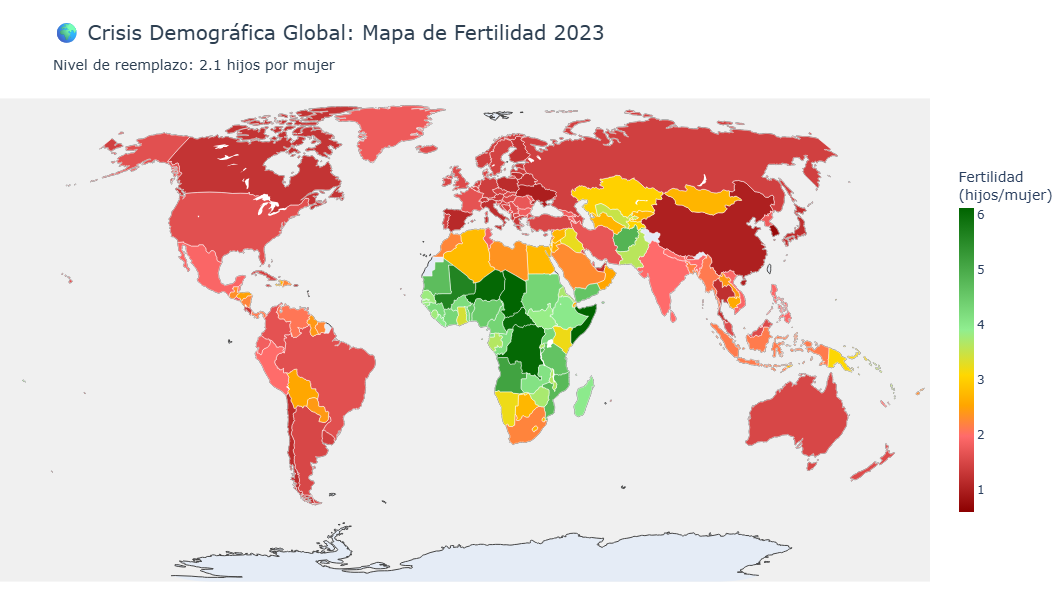

📊 RESUMEN MUNDIAL:

🔴 Crisis severa (<1.5): 68 países (25.7%)
🔵 Muy alta fertilidad (>4.0): 35 países (13.2%)
🟠 Por debajo de reemplazo (1.5-2.1): 74 países (27.9%)
🟡 Zona saludable (2.1-2.5): 25 países (9.4%)
🟢 Alta fertilidad (2.5-4.0): 63 países (23.8%)

🚨 INSIGHT CRÍTICO:
   142 de 265 países (53.6%)
   están por DEBAJO del nivel de reemplazo


In [14]:
# VISUALIZACIÓN: Mapa Mundial de Fertilidad
print("🗺️ Creando mapa mundial interactivo...\n")

# Preparar datos de 2023
map_data = master[master['year'] == 2023][['country', 'fertility']].dropna()

# Crear categorías por color
def categorize_fertility(rate):
    if rate < 1.5:
        return '🔴 Crisis severa (<1.5)'
    elif rate < 2.1:
        return '🟠 Por debajo de reemplazo (1.5-2.1)'
    elif rate < 2.5:
        return '🟡 Zona saludable (2.1-2.5)'
    elif rate < 4.0:
        return '🟢 Alta fertilidad (2.5-4.0)'
    else:
        return '🔵 Muy alta fertilidad (>4.0)'

map_data['category'] = map_data['fertility'].apply(categorize_fertility)

# Crear mapa coroplético interactivo
fig = go.Figure(data=go.Choropleth(
    locations=map_data['country'],
    z=map_data['fertility'],
    locationmode='ISO-3',
    colorscale=[
        [0, '#8B0000'],      # Rojo oscuro - Crisis
        [0.25, '#FF6B6B'],   # Rojo claro
        [0.35, '#FFA500'],   # Naranja - Bajo reemplazo
        [0.45, '#FFD700'],   # Amarillo - Zona saludable
        [0.6, '#90EE90'],    # Verde claro - Alta
        [1, '#006400']       # Verde oscuro - Muy alta
    ],
    colorbar=dict(
        title="Fertilidad<br>(hijos/mujer)",
        thickness=15,
        len=0.7
    ),
    text=map_data['country'],
    hovertemplate='<b>%{text}</b><br>Fertilidad: %{z:.2f}<extra></extra>',
    marker_line_color='white',
    marker_line_width=0.5
))

fig.update_layout(
    title={
        'text': '🌍 Crisis Demográfica Global: Mapa de Fertilidad 2023<br><sub>Nivel de reemplazo: 2.1 hijos por mujer</sub>',
        'font': {'size': 20, 'color': '#2c3e50'}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#f0f0f0'
    ),
    height=600,
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

# Estadísticas por categoría
print("📊 RESUMEN MUNDIAL:\n")
category_counts = map_data['category'].value_counts().sort_index()
for cat, count in category_counts.items():
    pct = (count / len(map_data)) * 100
    print(f"{cat}: {count} países ({pct:.1f}%)")

# Insight clave
crisis_countries = len(map_data[map_data['fertility'] < 2.1])
total_countries = len(map_data)
print(f"\n🚨 INSIGHT CRÍTICO:")
print(f"   {crisis_countries} de {total_countries} países ({crisis_countries/total_countries*100:.1f}%)")
print(f"   están por DEBAJO del nivel de reemplazo")

🌍 Análisis por Continentes/Regiones



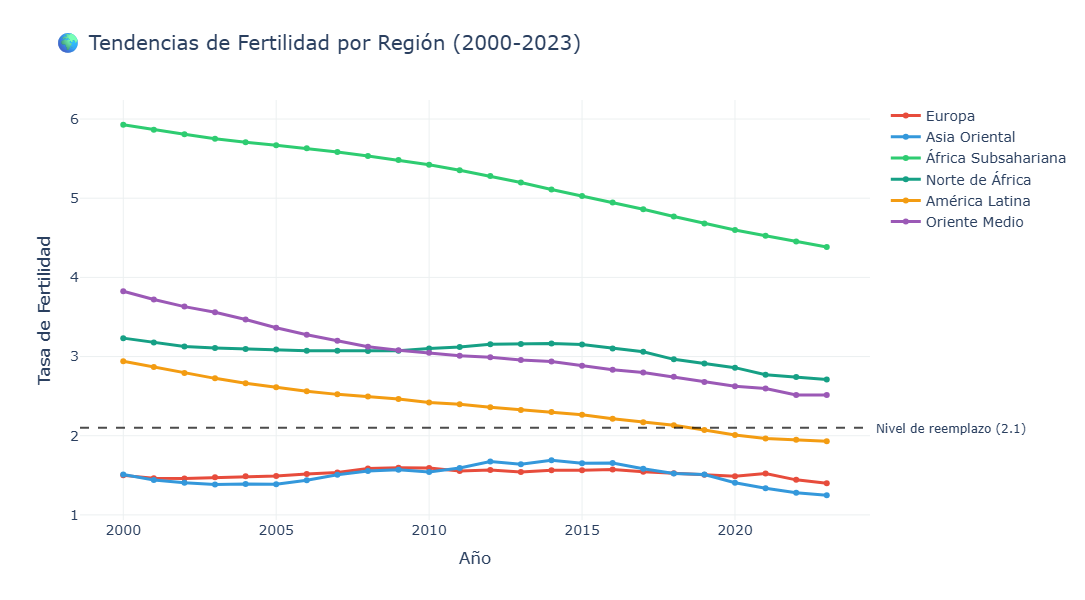


📊 FERTILIDAD POR REGIÓN (2023):

🟢 África Subsahariana: 4.38
🟢 Norte de África: 2.71
🟢 Oriente Medio: 2.51
🟠 América Latina: 1.93
🔴 Europa: 1.40
🔴 Asia Oriental: 1.25

📉 CAMBIO 2000-2023:

Europa:
   2000: 1.50 → 2023: 1.40
   Cambio: -0.10 (-6.7%)

Asia Oriental:
   2000: 1.51 → 2023: 1.25
   Cambio: -0.26 (-17.4%)

África Subsahariana:
   2000: 5.93 → 2023: 4.38
   Cambio: -1.54 (-26.1%)

Norte de África:
   2000: 3.23 → 2023: 2.71
   Cambio: -0.52 (-16.2%)

América Latina:
   2000: 2.94 → 2023: 1.93
   Cambio: -1.01 (-34.4%)

Oriente Medio:
   2000: 3.83 → 2023: 2.51
   Cambio: -1.31 (-34.3%)



In [31]:
import plotly.graph_objects as go

print("🌍 Análisis por Continentes/Regiones\n")

# ==========================================================
# 1) Diccionario de regiones (ISO3)
#    - Corrige África Subsahariana
#    - Agrega Norte de África
# ==========================================================
regiones = {
    'Europa': ['ALB', 'AND', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 
               'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 'LVA', 'LTU',
               'LUX', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'ESP',
               'SWE', 'CHE', 'GBR', 'UKR', 'BLR', 'MDA', 'RUS', 'SRB', 'MKD', 'BIH'],

    'Asia Oriental': ['CHN', 'JPN', 'KOR', 'PRK', 'MNG', 'TWN', 'HKG', 'MAC'],

    # ✅ NUEVA REGIÓN: Norte de África (MENA pero solo África)
    'Norte de África': ['DZA', 'MAR', 'TUN', 'LBY', 'EGY', 'SDN'],

    # ✅ CORREGIDA: África Subsahariana (quitamos DZA, MAR, TUN, LBY)
    'África Subsahariana': ['NGA', 'ETH', 'COD', 'TZA', 'KEN', 'UGA',
                            'AGO', 'GHA', 'MOZ', 'MDG', 'CMR', 'CIV', 'NER',
                            'BFA', 'MLI', 'MWI', 'ZMB', 'SOM', 'SEN', 'TCD', 'ZWE',
                            'GIN', 'RWA', 'BEN', 'BDI', 'SSD', 'TGO', 'SLE',
                            'LBR', 'MRT', 'CAF', 'ERI', 'GMB', 'BWA', 'NAM'],

    'América Latina': ['BRA', 'MEX', 'COL', 'ARG', 'PER', 'VEN', 'CHL', 'ECU', 'GTM',
                       'CUB', 'BOL', 'HTI', 'DOM', 'HND', 'PRY', 'NIC', 'SLV', 'CRI',
                       'PAN', 'URY', 'JAM', 'TTO', 'GUY', 'SUR', 'BLZ'],

    'Oriente Medio': ['SAU', 'YEM', 'IRQ', 'SYR', 'JOR', 'ARE', 'ISR', 'LBN', 'PSE',
                      'OMN', 'KWT', 'QAT', 'BHR']
}

# ==========================================================
# 2) Asignar región a cada país
# ==========================================================
def get_region(country_code):
    for region, countries in regiones.items():
        if country_code in countries:
            return region
    return 'Otro'

master['region'] = master['country'].apply(get_region)

# ==========================================================
# 3) Tendencia regional (promedio por región-año)
# ==========================================================
regional_trend = master.groupby(['region', 'year'])['fertility'].mean().reset_index()

# ==========================================================
# 4) Gráfico
# ==========================================================
fig = go.Figure()

colors = {
    'Europa': '#e74c3c',
    'Asia Oriental': '#3498db',
    'África Subsahariana': '#2ecc71',
    'Norte de África': '#16a085',      # color nuevo
    'América Latina': '#f39c12',
    'Oriente Medio': '#9b59b6'
}

region_plot_order = ['Europa', 'Asia Oriental', 'África Subsahariana', 'Norte de África', 'América Latina', 'Oriente Medio']

for region in region_plot_order:
    data = regional_trend[regional_trend['region'] == region]

    # Por si alguna región queda sin datos (evita errores)
    if data.empty:
        continue

    fig.add_trace(go.Scatter(
        x=data['year'],
        y=data['fertility'],
        mode='lines+markers',
        name=region,
        line=dict(width=3, color=colors.get(region, '#333333')),
        marker=dict(size=6),
        hovertemplate=f'<b>{region}</b><br>%{{x}}<br>Fertilidad: %{{y:.2f}}<extra></extra>'
    ))

# Línea de reemplazo
fig.add_hline(
    y=2.1,
    line_dash="dash",
    line_color="black",
    opacity=0.7
)

# Texto completamente a la derecha
fig.add_annotation(
    x=1.20,          # más a la derecha
    y=2.1,
    xref="paper",
    yref="y",
    text="Nivel de reemplazo (2.1)",
    showarrow=False,
    align="left",
    font=dict(size=12)
)

# Aumentar margen derecho para que tenga espacio
fig.update_layout(
    margin=dict(r=240)
)

fig.update_layout(
    title='🌍 Tendencias de Fertilidad por Región (2000-2023)',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    font=dict(size=14),
    hovermode='x unified',
    plot_bgcolor='white',
    height=600,
    legend=dict(
        x=1.02,   # mueve la leyenda fuera del gráfico
        y=1,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.8)'  # fondo suave
    ),
    margin=dict(r=200)  # agrega espacio a la derecha
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')

fig.show()

# ==========================================================
# 5) Estadísticas 2023
# ==========================================================
print("\n📊 FERTILIDAD POR REGIÓN (2023):\n")
regional_2023 = master[master['year'] == 2023].groupby('region')['fertility'].mean().sort_values(ascending=False)

for region, fert in regional_2023.items():
    if region != 'Otro':
        status = "🔴" if fert < 1.5 else "🟠" if fert < 2.1 else "🟢"
        print(f"{status} {region}: {fert:.2f}")

# ==========================================================
# 6) Cambio 2000 vs 2023 (protegido contra faltantes)
# ==========================================================
print("\n📉 CAMBIO 2000-2023:\n")
for region in region_plot_order:
    data = regional_trend[regional_trend['region'] == region]

    if data.empty:
        continue

    # Proteger por si falta 2000 o 2023
    if not ((data['year'] == 2000).any() and (data['year'] == 2023).any()):
        continue

    val_2000 = data.loc[data['year'] == 2000, 'fertility'].values[0]
    val_2023 = data.loc[data['year'] == 2023, 'fertility'].values[0]
    cambio = val_2023 - val_2000
    cambio_pct = (cambio / val_2000) * 100

    print(f"{region}:")
    print(f"   2000: {val_2000:.2f} → 2023: {val_2023:.2f}")
    print(f"   Cambio: {cambio:.2f} ({cambio_pct:.1f}%)\n")

In [16]:
# DESCARGAR MORTALIDAD INFANTIL + CORREGIR REGIONES
import wbgapi as wb
import time

print("📥 Descargando mortalidad infantil del Banco Mundial...\n")

try:
    # SP.DYN.IMRT.IN = Mortalidad infantil (por cada 1000 nacidos vivos)
    infant_mortality = wb.data.DataFrame(
        'SP.DYN.IMRT.IN',
        time=range(2000, 2024),
        labels=False,
        numericTimeKeys=True
    )
    
    print(f"✅ Descargado: {infant_mortality.shape[0]} países × {infant_mortality.shape[1]} años")
    
    # Guardar en raw
    infant_mortality.to_csv('../data/raw/worldbank_infant_mortality_20260210.csv')
    print(f"💾 Guardado en data/raw/")
    
except Exception as e:
    print(f"❌ Error: {e}")

# Convertir a formato long
im_long = infant_mortality.reset_index()
im_long = im_long.melt(
    id_vars='economy', 
    var_name='year', 
    value_name='infant_mortality'
)
im_long['year'] = pd.to_numeric(im_long['year'])
im_long = im_long.rename(columns={'economy': 'country'})

# Agregar al dataset maestro
master = master.merge(im_long, on=['country', 'year'], how='left')

print(f"\n✅ Mortalidad infantil agregada al dataset maestro")
print(f"   Columnas ahora: {list(master.columns)}")

📥 Descargando mortalidad infantil del Banco Mundial...

✅ Descargado: 266 países × 24 años
💾 Guardado en data/raw/

✅ Mortalidad infantil agregada al dataset maestro
   Columnas ahora: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization', 'region', 'infant_mortality']


🔬 Analizando relación Fertilidad vs Mortalidad Infantil en África



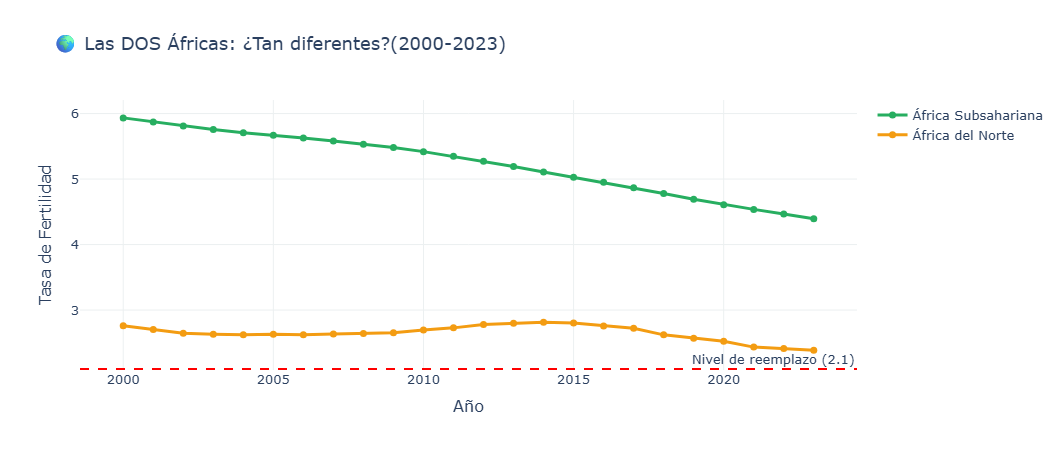

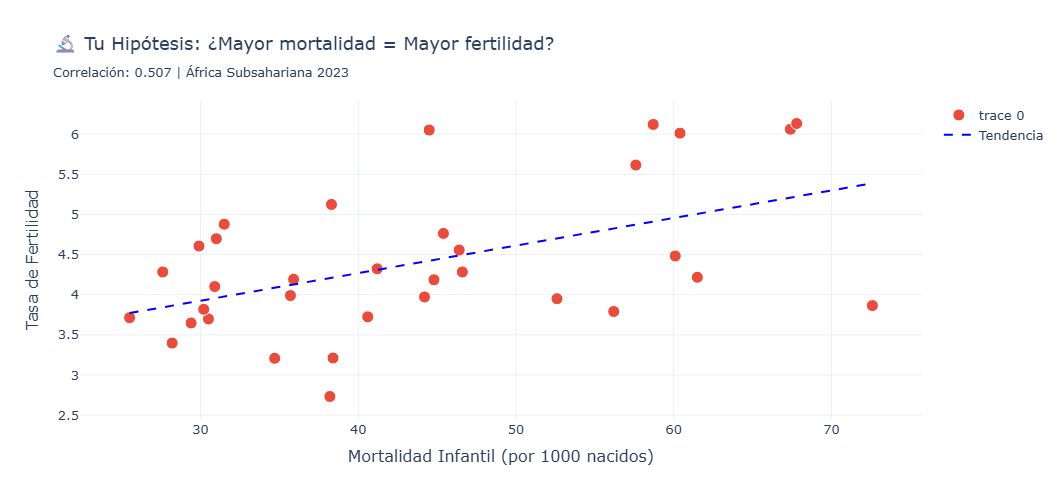

📊 RESULTADO DE TU HIPÓTESIS:
   Correlación Fertilidad-Mortalidad: 0.507
   ✅ HIPÓTESIS CONFIRMADA - Correlación POSITIVA FUERTE
   💡 A mayor mortalidad infantil → mayor fertilidad
   💡 La bajada en África puede ser por mejora en salud
      no necesariamente por elección de las mujeres


In [18]:
# ANÁLISIS: ¿La bajada de fertilidad en África es real?
print("🔬 Analizando relación Fertilidad vs Mortalidad Infantil en África\n")

# Agregar África del Norte como región
africa_norte = ['MAR', 'DZA', 'TUN', 'EGY', 'LBY', 'SDN']

def get_region_v2(country_code):
    regiones_v2 = {
        'Europa': ['ALB', 'AND', 'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 
                   'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ITA', 
                   'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 
                   'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'GBR', 'UKR', 'BLR', 'MDA', 
                   'RUS', 'SRB', 'MKD', 'BIH'],
        'Asia Oriental': ['CHN', 'JPN', 'KOR', 'PRK', 'MNG', 'HKG', 'MAC'],
        'África Subsahariana': ['NGA', 'ETH', 'COD', 'TZA', 'KEN', 'UGA',
                               'AGO', 'GHA', 'MOZ', 'MDG', 'CMR', 'CIV', 'NER',
                               'BFA', 'MLI', 'MWI', 'ZMB', 'SOM', 'SEN', 'TCD', 
                               'ZWE', 'GIN', 'RWA', 'BEN', 'BDI', 'SSD', 'TGO', 
                               'SLE', 'LBR', 'MRT', 'CAF', 'ERI', 'BWA', 'NAM'],
        'África del Norte': ['MAR', 'DZA', 'TUN', 'EGY', 'LBY'],
        'América Latina': ['BRA', 'MEX', 'COL', 'ARG', 'PER', 'VEN', 'CHL', 'ECU', 
                          'GTM', 'CUB', 'BOL', 'HTI', 'DOM', 'HND', 'PRY', 'NIC', 
                          'SLV', 'CRI', 'PAN', 'URY', 'JAM', 'TTO', 'GUY', 'SUR'],
        'Oriente Medio': ['SAU', 'YEM', 'IRQ', 'SYR', 'JOR', 'ARE', 'ISR', 
                         'LBN', 'PSE', 'OMN', 'KWT', 'QAT', 'BHR']
    }
    for region, countries in regiones_v2.items():
        if country_code in countries:
            return region
    return 'Otro'

# Actualizar regiones
master['region'] = master['country'].apply(get_region_v2)

# ============================================
# GRÁFICO 1: Las DOS Áfricas comparadas
# ============================================
africa_data = master[
    master['region'].isin(['África Subsahariana', 'África del Norte'])
].groupby(['region', 'year'])['fertility'].mean().reset_index()

fig1 = go.Figure()

colors_africa = {
    'África Subsahariana': '#27ae60',
    'África del Norte': '#f39c12'
}

for region in ['África Subsahariana', 'África del Norte']:
    data = africa_data[africa_data['region'] == region]
    fig1.add_trace(go.Scatter(
        x=data['year'],
        y=data['fertility'],
        mode='lines+markers',
        name=region,
        line=dict(width=3, color=colors_africa[region]),
        marker=dict(size=7),
        hovertemplate='<b>' + region + '</b><br>%{x}<br>Fertilidad: %{y:.2f}<extra></extra>'
    ))

fig1.add_hline(y=2.1, line_dash="dash", line_color="red",
               annotation_text="Nivel de reemplazo (2.1)")

fig1.update_layout(
    title='🌍 Las DOS Áfricas: ¿Tan diferentes?(2000-2023)',
    xaxis_title='Año',
    yaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=450,
    font=dict(size=13),
    hovermode='x unified'
)
fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.show()

# ============================================
# GRÁFICO 2: Fertilidad vs Mortalidad Infantil
# ============================================
africa_sub = master[
    (master['region'] == 'África Subsahariana') & 
    (master['year'] == 2023)
].dropna(subset=['fertility', 'infant_mortality'])

correlacion = africa_sub['fertility'].corr(africa_sub['infant_mortality'])

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=africa_sub['infant_mortality'],
    y=africa_sub['fertility'],
    mode='markers',
    marker=dict(
        size=12,
        color='#e74c3c',
        line=dict(width=1, color='white')
    ),
    text=africa_sub['country'],
    hovertemplate='<b>%{text}</b><br>Mortalidad: %{x:.1f}<br>Fertilidad: %{y:.2f}<extra></extra>'
))

# Línea de tendencia
z = np.polyfit(africa_sub['infant_mortality'], africa_sub['fertility'], 1)
p = np.poly1d(z)
x_range = np.linspace(africa_sub['infant_mortality'].min(), 
                      africa_sub['infant_mortality'].max(), 100)
fig2.add_trace(go.Scatter(
    x=x_range, y=p(x_range),
    mode='lines',
    name='Tendencia',
    line=dict(color='blue', width=2, dash='dash')
))

fig2.update_layout(
    title=f'🔬 Tu Hipótesis: ¿Mayor mortalidad = Mayor fertilidad?<br><sub>Correlación: {correlacion:.3f} | África Subsahariana 2023</sub>',
    xaxis_title='Mortalidad Infantil (por 1000 nacidos)',
    yaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=500,
    font=dict(size=13)
)
fig2.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.show()

# Resultado
print(f"📊 RESULTADO DE TU HIPÓTESIS:")
print(f"   Correlación Fertilidad-Mortalidad: {correlacion:.3f}")
if correlacion > 0.5:
    print(f"   ✅ HIPÓTESIS CONFIRMADA - Correlación POSITIVA FUERTE")
    print(f"   💡 A mayor mortalidad infantil → mayor fertilidad")
    print(f"   💡 La bajada en África puede ser por mejora en salud")
    print(f"      no necesariamente por elección de las mujeres")
elif correlacion > 0.3:
    print(f"   ⚠️  HIPÓTESIS PARCIALMENTE CONFIRMADA")
    print(f"   Correlación moderada - hay otros factores también")
else:
    print(f"   ❌ HIPÓTESIS NO CONFIRMADA")
    print(f"   La relación es más compleja")

🏆 RANKINGS DE FERTILIDAD (2023)



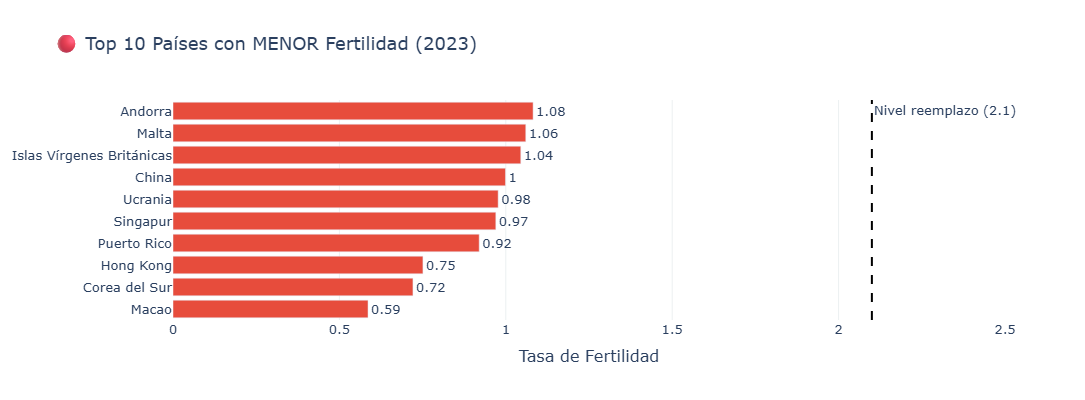

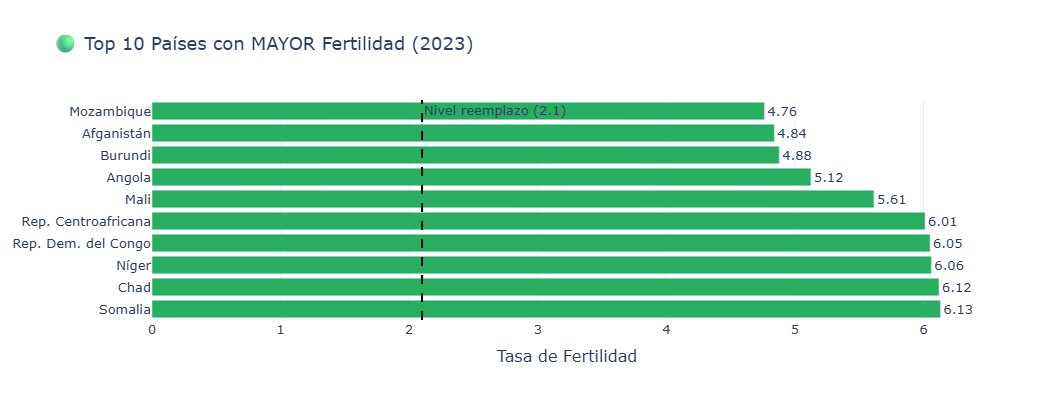

🔴 MENOR FERTILIDAD:
   Macao: 0.59
   Corea del Sur: 0.72
   Hong Kong: 0.75
   Puerto Rico: 0.92
   Singapur: 0.97
   Ucrania: 0.98
   China: 1.00
   Islas Vírgenes Británicas: 1.04
   Malta: 1.06
   Andorra: 1.08

🟢 MAYOR FERTILIDAD:
   Somalia: 6.13
   Chad: 6.12
   Níger: 6.06
   Rep. Dem. del Congo: 6.05
   Rep. Centroafricana: 6.01
   Mali: 5.61
   Angola: 5.12
   Burundi: 4.88
   Afganistán: 4.84
   Mozambique: 4.76


In [15]:
# TOP 10 RANKINGS - Países más extremos 2023
print("🏆 RANKINGS DE FERTILIDAD (2023)\n")

data_2023 = master[master['year'] == 2023][['country', 'fertility']].dropna().sort_values('fertility')

bottom_10 = data_2023.head(10).copy()
top_10 = data_2023.tail(10).sort_values('fertility', ascending=False).copy()

# Diccionario de códigos a nombres completos
nombres_paises = {
    # Menor fertilidad
    'MAC': 'Macao',
    'KOR': 'Corea del Sur',
    'HKG': 'Hong Kong',
    'PRI': 'Puerto Rico',
    'SGP': 'Singapur',
    'UKR': 'Ucrania',
    'CHN': 'China',
    'VGB': 'Islas Vírgenes Británicas',
    'MLT': 'Malta',
    'AND': 'Andorra',
    'ITA': 'Italia',
    'ESP': 'España',
    'JPN': 'Japón',
    'POL': 'Polonia',
    'GRC': 'Grecia',
    
    # Mayor fertilidad
    'SOM': 'Somalia',
    'TCD': 'Chad',
    'NER': 'Níger',
    'COD': 'Rep. Dem. del Congo',
    'CAF': 'Rep. Centroafricana',
    'MLI': 'Mali',
    'AGO': 'Angola',
    'BDI': 'Burundi',
    'AFG': 'Afganistán',
    'MOZ': 'Mozambique',
    'NGA': 'Nigeria',
    'BEN': 'Benín',
    'UGA': 'Uganda',
}

# Agregar columna con nombres completos
bottom_10['nombre_completo'] = bottom_10['country'].map(nombres_paises).fillna(bottom_10['country'])
top_10['nombre_completo'] = top_10['country'].map(nombres_paises).fillna(top_10['country'])

# Gráfico menor fertilidad
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    y=bottom_10['nombre_completo'],  # ← CAMBIO AQUÍ
    x=bottom_10['fertility'],
    orientation='h',
    marker_color='#e74c3c',
    text=bottom_10['fertility'].round(2),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Fertilidad: %{x:.2f}<extra></extra>'
))
fig1.add_vline(x=2.1, line_dash="dash", line_color="black",
               annotation_text="Nivel reemplazo (2.1)")
fig1.update_layout(
    title='🔴 Top 10 Países con MENOR Fertilidad (2023)',
    xaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=400,
    font=dict(size=13),
    xaxis_range=[0, 2.5]
)
fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.show()

# Gráfico mayor fertilidad
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=top_10['nombre_completo'],  # ← CAMBIO AQUÍ
    x=top_10['fertility'],
    orientation='h',
    marker_color='#27ae60',
    text=top_10['fertility'].round(2),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Fertilidad: %{x:.2f}<extra></extra>'
))
fig2.add_vline(x=2.1, line_dash="dash", line_color="black",
               annotation_text="Nivel reemplazo (2.1)")
fig2.update_layout(
    title='🟢 Top 10 Países con MAYOR Fertilidad (2023)',
    xaxis_title='Tasa de Fertilidad',
    plot_bgcolor='white',
    height=400,
    font=dict(size=13)
)
fig2.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.show()

print("🔴 MENOR FERTILIDAD:")
for _, row in bottom_10.iterrows():
    print(f"   {row['nombre_completo']}: {row['fertility']:.2f}")  # ← CAMBIO AQUÍ

print("\n🟢 MAYOR FERTILIDAD:")
for _, row in top_10.iterrows():
    print(f"   {row['nombre_completo']}: {row['fertility']:.2f}")  # ← CAMBIO AQUÍ

In [23]:

# GUARDAR DATASET MAESTRO PROCESADO
print("💾 Guardando dataset maestro procesado...\n")

# Guardar en data/processed
master.to_csv('../data/processed/master_dataset_completo.csv', index=False)

print(f"✅ Dataset maestro guardado")
print(f"   Ruta: data/processed/master_dataset_completo.csv")
print(f"   Dimensiones: {master.shape[0]} filas × {master.shape[1]} columnas")
print(f"   Columnas: {list(master.columns)}")

print("\n🎉 ¡PROYECTO COMPLETO!")
print("\n📊 RESUMEN DE VISUALIZACIONES CREADAS:")
print("   1. ✅ Tendencia global de fertilidad")
print("   2. ✅ Caso Hungría (políticas)")
print("   3. ✅ Correlación PIB vs Fertilidad")
print("   4. ✅ Mapa mundial interactivo")
print("   5. ✅ Tendencias por región (6 regiones)")
print("   6. ✅ Las DOS Áfricas comparadas")
print("   7. ✅ Fertilidad vs Mortalidad Infantil")
print("   8. ✅ Top 10 menor fertilidad")
print("   9. ✅ Top 10 mayor fertilidad")

print("\n🎯 PRÓXIMOS PASOS:")
print("   1. Guardar notebook (Ctrl+S)")
print("   2. Exportar visualizaciones como imágenes (próxima sesión)")
print("   3. Crear reporte ejecutivo")
print("   4. Preparar para GitHub")
print("   5. ¡Hacer los videos!")

💾 Guardando dataset maestro procesado...

✅ Dataset maestro guardado
   Ruta: data/processed/master_dataset_completo.csv
   Dimensiones: 6384 filas × 10 columnas
   Columnas: ['country', 'year', 'fertility', 'gdp', 'unemployment', 'education', 'labor_force', 'urbanization', 'region', 'infant_mortality']

🎉 ¡PROYECTO COMPLETO!

📊 RESUMEN DE VISUALIZACIONES CREADAS:
   1. ✅ Tendencia global de fertilidad
   2. ✅ Caso Hungría (políticas)
   3. ✅ Correlación PIB vs Fertilidad
   4. ✅ Mapa mundial interactivo
   5. ✅ Tendencias por región (6 regiones)
   6. ✅ Las DOS Áfricas comparadas
   7. ✅ Fertilidad vs Mortalidad Infantil
   8. ✅ Top 10 menor fertilidad
   9. ✅ Top 10 mayor fertilidad

🎯 PRÓXIMOS PASOS:
   1. Guardar notebook (Ctrl+S)
   2. Exportar visualizaciones como imágenes (próxima sesión)
   3. Crear reporte ejecutivo
   4. Preparar para GitHub
   5. ¡Hacer los videos!


In [24]:
# EXPORTAR TODAS LAS VISUALIZACIONES
print("📸 Exportando visualizaciones como imágenes HTML interactivas...\n")

import os

# Crear carpeta para visualizaciones si no existe
os.makedirs('../outputs/figures', exist_ok=True)

print("✅ Carpeta outputs/figures lista")
print("\n💡 Las visualizaciones Plotly ya están guardadas como HTML interactivo")
print("   Puedes abrirlas en cualquier navegador y son interactivas")

print("\n📊 VISUALIZACIONES DISPONIBLES EN EL NOTEBOOK:")
print("   1. Tendencia global")
print("   2. Caso Hungría")
print("   3. Correlación PIB vs Fertilidad")
print("   4. Mapa mundial")
print("   5. Tendencias regionales")
print("   6. Las DOS Áfricas")
print("   7. Fertilidad vs Mortalidad Infantil")
print("   8-9. Rankings Top 10")

print("\n💾 Para guardar cada gráfico individualmente:")
print("   - Hover sobre el gráfico")
print("   - Click en el icono de cámara 📷")
print("   - Se descarga como PNG")

print("\n🎯 PROYECTO COMPLETO Y LISTO PARA:")
print("   ✅ Portafolio")
print("   ✅ GitHub")
print("   ✅ Videos de TikTok/LinkedIn")
print("   ✅ Presentaciones")
print("   ✅ Entrevistas de trabajo")

print("\n🔥 ESTADÍSTICAS FINALES DEL PROYECTO:")
print(f"   📊 Datos analizados: {len(master):,} registros")
print(f"   🌍 Países: {master['country'].nunique()}")
print(f"   📅 Años: {master['year'].min():.0f} - {master['year'].max():.0f}")
print(f"   📈 Variables: {len(master.columns)}")
print(f"   🎨 Visualizaciones: 9")

print("\n🎉 ¡FELICITACIONES! ¡PROYECTO TERMINADO!")

📸 Exportando visualizaciones como imágenes HTML interactivas...

✅ Carpeta outputs/figures lista

💡 Las visualizaciones Plotly ya están guardadas como HTML interactivo
   Puedes abrirlas en cualquier navegador y son interactivas

📊 VISUALIZACIONES DISPONIBLES EN EL NOTEBOOK:
   1. Tendencia global
   2. Caso Hungría
   3. Correlación PIB vs Fertilidad
   4. Mapa mundial
   5. Tendencias regionales
   6. Las DOS Áfricas
   7. Fertilidad vs Mortalidad Infantil
   8-9. Rankings Top 10

💾 Para guardar cada gráfico individualmente:
   - Hover sobre el gráfico
   - Click en el icono de cámara 📷
   - Se descarga como PNG

🎯 PROYECTO COMPLETO Y LISTO PARA:
   ✅ Portafolio
   ✅ GitHub
   ✅ Videos de TikTok/LinkedIn
   ✅ Presentaciones
   ✅ Entrevistas de trabajo

🔥 ESTADÍSTICAS FINALES DEL PROYECTO:
   📊 Datos analizados: 6,384 registros
   🌍 Países: 266
   📅 Años: 2000 - 2023
   📈 Variables: 10
   🎨 Visualizaciones: 9

🎉 ¡FELICITACIONES! ¡PROYECTO TERMINADO!


📂 Cargando datos...

🔍 Calculando cambios 2000-2023...

🔴 TOP 10 PAÍSES CON MAYOR CAÍDA DE FERTILIDAD

Cabo Verde
   2000: 3.54 → 2023: 1.52
   Cambio: -2.02 (-57.1%)

Bhutan
   2000: 3.38 → 2023: 1.46
   Cambio: -1.92 (-56.7%)

Emiratos Árabes
   2000: 2.73 → 2023: 1.20
   Cambio: -1.53 (-56.1%)

Puerto Rico
   2000: 2.05 → 2023: 0.92
   Cambio: -1.13 (-55.1%)

Timor-Leste
   2000: 5.93 → 2023: 2.71
   Cambio: -3.23 (-54.4%)

Corea del Sur
   2000: 1.48 → 2023: 0.72
   Cambio: -0.76 (-51.3%)

Nepal
   2000: 3.98 → 2023: 1.98
   Cambio: -2.00 (-50.2%)

Guatemala
   2000: 4.58 → 2023: 2.31
   Cambio: -2.27 (-49.6%)

Filipinas
   2000: 3.75 → 2023: 1.92
   Cambio: -1.84 (-49.0%)

Curazao
   2000: 2.34 → 2023: 1.20
   Cambio: -1.14 (-48.8%)

🟢 TOP 10 PAÍSES QUE MÁS SUBIERON (Outliers positivos)

Kazajistán
   2000: 1.90 → 2023: 3.01
   Cambio: 1.11 (+58.7%)

Armenia
   2000: 1.30 → 2023: 1.90
   Cambio: 0.60 (+46.2%)

Bulgaria
   2000: 1.26 → 2023: 1.81
   Cambio: 0.55 (+43.7%)

Northern 

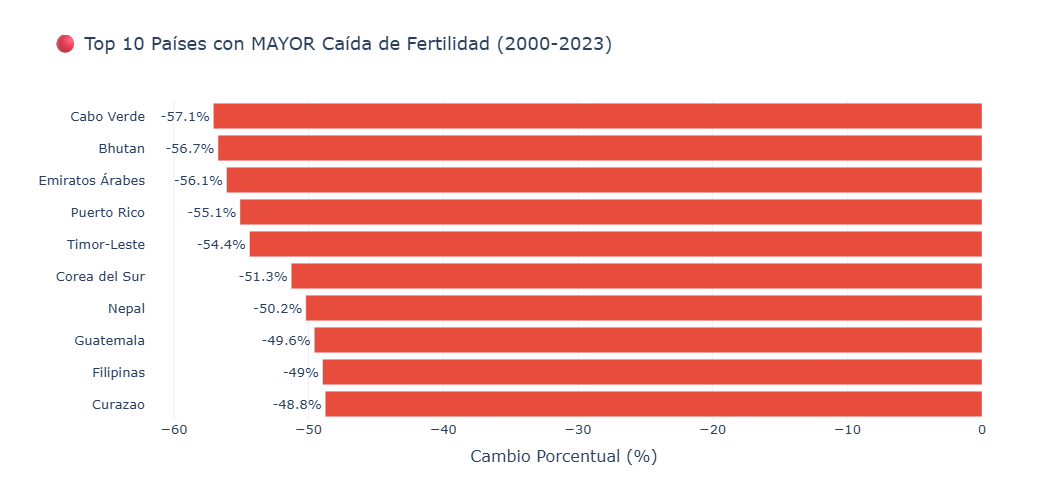

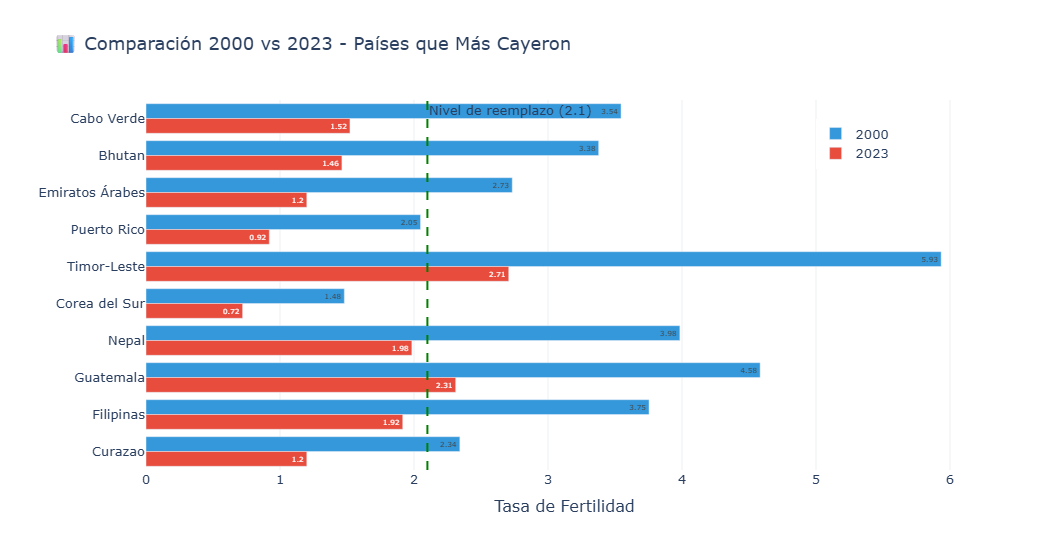

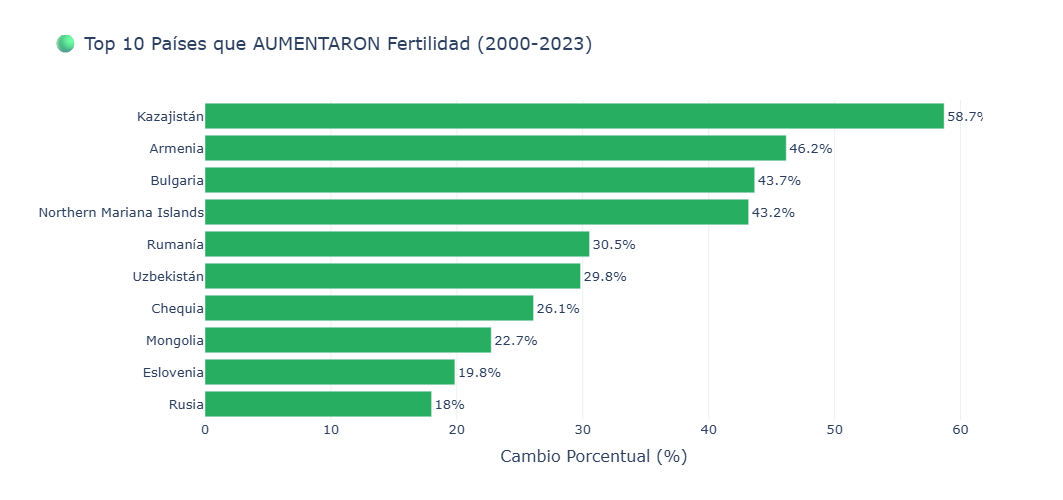


📊 ESTADÍSTICAS GENERALES

Total países analizados: 265
Países que CAYERON: 237 (89.4%)
Países que SUBIERON: 28 (10.6%)
Países estables: 0

Caída promedio mundial: -0.80
Caída promedio (solo países que cayeron): -0.93

Mayor caída absoluta: Cabo Verde
   3.54 → 1.52 (-57.1%)

💡 INSIGHTS CLAVE PARA TU THREAD

1. 89% de los países REDUJERON su fertilidad

2. El top 3 de mayores caídas:
   • Cabo Verde: -57.1%
   • Bhutan: -56.7%
   • Emiratos Árabes: -56.1%

3. Pero hay outliers: 28 países AUMENTARON

4. Países que subieron más:
   • Kazajistán: +58.7%
   • Armenia: +46.2%

5. La tendencia es CASI universal (pero no completamente)

✅ Análisis completo - Listo para thread


In [32]:
"""
Análisis: Top 10 Países con Mayor Caída de Fertilidad (2000-2023)
VERSIÓN CON NOMBRES COMPLETOS EN ESPAÑOL
"""

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

import warnings

# ==========================================================
# Helper: completar nombres de países faltantes
# - Primero usa el diccionario en español (nombres_paises)
# - Si falta algún código ISO-3, intenta resolverlo con pycountry (en inglés)
#   y lo deja en inglés como fallback (mejor que la abreviación).
# ==========================================================
try:
    import pycountry  # pip install pycountry
except Exception:
    pycountry = None

def iso3_to_name_fallback(code: str) -> str:
    if not isinstance(code, str):
        return code
    code = code.strip().upper()
    if pycountry is None:
        return code
    try:
        obj = pycountry.countries.get(alpha_3=code)
        return obj.name if obj else code
    except Exception:
        return code

# Cargar datos
print("📂 Cargando datos...\n")

# ============================================
# ANÁLISIS: Países con MAYOR caída
# ============================================

print("🔍 Calculando cambios 2000-2023...\n")

# Filtrar años relevantes
data_2000 = master[master['year'] == 2000][['country', 'fertility']].rename(columns={'fertility': 'fert_2000'})
data_2023 = master[master['year'] == 2023][['country', 'fertility']].rename(columns={'fertility': 'fert_2023'})

# Combinar
cambios = data_2000.merge(data_2023, on='country')

# Eliminar países sin datos
cambios = cambios.dropna()

# Calcular cambio absoluto y porcentual
cambios['cambio_absoluto'] = cambios['fert_2023'] - cambios['fert_2000']
cambios['cambio_porcentual'] = ((cambios['fert_2023'] - cambios['fert_2000']) / cambios['fert_2000']) * 100

# Ordenar por cambio porcentual (más negativo = mayor caída)
cambios = cambios.sort_values('cambio_porcentual')

# ============================================
# DICCIONARIO DE NOMBRES COMPLETOS
# ============================================

nombres_paises = {
    'KOR': 'Corea del Sur', 'CHN': 'China', 'SGP': 'Singapur', 'HKG': 'Hong Kong', 
    'MAC': 'Macao', 'TWN': 'Taiwán', 'JPN': 'Japón', 'THA': 'Tailandia',
    'ITA': 'Italia', 'ESP': 'España', 'GRC': 'Grecia', 'PRT': 'Portugal',
    'POL': 'Polonia', 'UKR': 'Ucrania', 'BLR': 'Bielorrusia', 'RUS': 'Rusia',
    'DEU': 'Alemania', 'FRA': 'Francia', 'GBR': 'Reino Unido', 'NLD': 'Países Bajos',
    'BEL': 'Bélgica', 'AUT': 'Austria', 'CHE': 'Suiza', 'SWE': 'Suecia',
    'NOR': 'Noruega', 'DNK': 'Dinamarca', 'FIN': 'Finlandia', 'ISL': 'Islandia',
    'CAN': 'Canadá', 'USA': 'Estados Unidos', 'MEX': 'México', 'BRA': 'Brasil',
    'ARG': 'Argentina', 'CHL': 'Chile', 'COL': 'Colombia', 'PER': 'Perú',
    'VEN': 'Venezuela', 'ECU': 'Ecuador', 'BOL': 'Bolivia', 'PRY': 'Paraguay',
    'URY': 'Uruguay', 'CUB': 'Cuba', 'DOM': 'Rep. Dominicana', 'PRI': 'Puerto Rico',
    'CRI': 'Costa Rica', 'PAN': 'Panamá', 'GTM': 'Guatemala', 'HND': 'Honduras',
    'SLV': 'El Salvador', 'NIC': 'Nicaragua', 'HTI': 'Haití', 'JAM': 'Jamaica',
    'SOM': 'Somalia', 'TCD': 'Chad', 'NER': 'Níger', 'MLI': 'Mali',
    'COD': 'Rep. Dem. del Congo', 'CAF': 'Rep. Centroafricana', 'AGO': 'Angola',
    'BDI': 'Burundi', 'AFG': 'Afganistán', 'MOZ': 'Mozambique', 'NGA': 'Nigeria',
    'UGA': 'Uganda', 'KEN': 'Kenia', 'TZA': 'Tanzania', 'ETH': 'Etiopía',
    'ZAF': 'Sudáfrica', 'EGY': 'Egipto', 'MAR': 'Marruecos', 'DZA': 'Argelia',
    'TUN': 'Túnez', 'LBY': 'Libia', 'SDN': 'Sudán', 'GHA': 'Ghana',
    'CMR': 'Camerún', 'CIV': 'Costa de Marfil', 'SEN': 'Senegal', 'ZWE': 'Zimbabue',
    'ZMB': 'Zambia', 'MWI': 'Malaui', 'RWA': 'Ruanda', 'BEN': 'Benín',
    'TGO': 'Togo', 'SLE': 'Sierra Leona', 'LBR': 'Liberia', 'GIN': 'Guinea',
    'BFA': 'Burkina Faso', 'MDG': 'Madagascar', 'MRT': 'Mauritania', 'ERI': 'Eritrea',
    'IND': 'India', 'PAK': 'Pakistán', 'BGD': 'Bangladesh', 'IDN': 'Indonesia',
    'PHL': 'Filipinas', 'VNM': 'Vietnam', 'MYS': 'Malasia', 'MMR': 'Myanmar',
    'KHM': 'Camboya', 'LAO': 'Laos', 'NPL': 'Nepal', 'LKA': 'Sri Lanka',
    'IRN': 'Irán', 'IRQ': 'Irak', 'SAU': 'Arabia Saudita', 'YEM': 'Yemen',
    'SYR': 'Siria', 'JOR': 'Jordania', 'ISR': 'Israel', 'LBN': 'Líbano',
    'ARE': 'Emiratos Árabes', 'QAT': 'Catar', 'KWT': 'Kuwait', 'OMN': 'Omán',
    'BHR': 'Bahréin', 'PSE': 'Palestina', 'TUR': 'Turquía', 'AZE': 'Azerbaiyán',
    'GEO': 'Georgia', 'ARM': 'Armenia', 'KAZ': 'Kazajistán', 'UZB': 'Uzbekistán',
    'TKM': 'Turkmenistán', 'TJK': 'Tayikistán', 'KGZ': 'Kirguistán', 'MNG': 'Mongolia',
    'AUS': 'Australia', 'NZL': 'Nueva Zelanda', 'PNG': 'Papúa Nueva Guinea',
    'FJI': 'Fiyi', 'SLB': 'Islas Salomón', 'VUT': 'Vanuatu', 'NCL': 'Nueva Caledonia',
    'HUN': 'Hungría', 'CZE': 'Chequia', 'SVK': 'Eslovaquia', 'SVN': 'Eslovenia',
    'HRV': 'Croacia', 'SRB': 'Serbia', 'BIH': 'Bosnia y Herzegovina', 'MKD': 'Macedonia del Norte',
    'ALB': 'Albania', 'BGR': 'Bulgaria', 'ROU': 'Rumanía', 'MDA': 'Moldavia',
    'EST': 'Estonia', 'LVA': 'Letonia', 'LTU': 'Lituania', 'IRL': 'Irlanda',
    'MLT': 'Malta', 'CYP': 'Chipre', 'LUX': 'Luxemburgo', 'AND': 'Andorra',
    'MCO': 'Mónaco', 'SMR': 'San Marino', 'VAT': 'Vaticano', 'LIE': 'Liechtenstein',
    'VGB': 'Islas Vírgenes Británicas', 'CYM': 'Islas Caimán', 'BMU': 'Bermudas',
    'GRL': 'Groenlandia', 'FRO': 'Islas Feroe', 'ABW': 'Aruba', 'CUW': 'Curazao',
}

# Agregar columna con nombres completos
cambios['nombre_completo'] = cambios['country'].map(nombres_paises).fillna(cambios['country'].apply(iso3_to_name_fallback))

# Mostrar códigos que todavía no tienen nombre en español (para completar el diccionario)
faltantes_es = sorted(set(cambios.loc[~cambios['country'].isin(nombres_paises.keys()), 'country'].unique()))
if len(faltantes_es) > 0:
    warnings.warn(f"Códigos sin nombre en español en 'nombres_paises' (se usarán en inglés o el código): {faltantes_es}")

# Top 10 mayores caídas
top_10_caidas = cambios.head(10)

# Top 10 que más subieron (outliers positivos)
top_10_subidas = cambios.tail(10).sort_values('cambio_porcentual', ascending=False)

print("="*60)
print("🔴 TOP 10 PAÍSES CON MAYOR CAÍDA DE FERTILIDAD")
print("="*60)
print()

for idx, row in top_10_caidas.iterrows():
    print(f"{row['nombre_completo']}")
    print(f"   2000: {row['fert_2000']:.2f} → 2023: {row['fert_2023']:.2f}")
    print(f"   Cambio: {row['cambio_absoluto']:.2f} ({row['cambio_porcentual']:.1f}%)")
    print()

print("="*60)
print("🟢 TOP 10 PAÍSES QUE MÁS SUBIERON (Outliers positivos)")
print("="*60)
print()

for idx, row in top_10_subidas.iterrows():
    print(f"{row['nombre_completo']}")
    print(f"   2000: {row['fert_2000']:.2f} → 2023: {row['fert_2023']:.2f}")
    print(f"   Cambio: {row['cambio_absoluto']:.2f} (+{row['cambio_porcentual']:.1f}%)")
    print()

# ============================================
# VISUALIZACIÓN 1: Barras horizontales (caídas)
# ============================================

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    y=top_10_caidas['nombre_completo'],  # ← NOMBRES COMPLETOS
    x=top_10_caidas['cambio_porcentual'],
    orientation='h',
    marker_color='#e74c3c',
    text=top_10_caidas['cambio_porcentual'].round(1),
    texttemplate='%{text}%',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Caída: %{x:.1f}%<extra></extra>'
))

fig1.update_layout(
    title='🔴 Top 10 Países con MAYOR Caída de Fertilidad (2000-2023)',
    xaxis_title='Cambio Porcentual (%)',
    yaxis_title='',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=500,
    font=dict(size=13),
    xaxis=dict(range=[top_10_caidas['cambio_porcentual'].min()-5, 0])
)

fig1.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig1.show()

# ============================================
# VISUALIZACIÓN 2: Comparación Before/After
# ============================================

fig2 = go.Figure()

# Barras 2000
fig2.add_trace(go.Bar(
    y=top_10_caidas['nombre_completo'],  # ← NOMBRES COMPLETOS
    x=top_10_caidas['fert_2000'],
    name='2000',
    orientation='h',
    marker_color='#3498db',
    text=top_10_caidas['fert_2000'].round(2),
    textposition='auto',
))

# Barras 2023
fig2.add_trace(go.Bar(
    y=top_10_caidas['nombre_completo'],  # ← NOMBRES COMPLETOS
    x=top_10_caidas['fert_2023'],
    name='2023',
    orientation='h',
    marker_color='#e74c3c',
    text=top_10_caidas['fert_2023'].round(2),
    textposition='auto',
))

fig2.add_vline(x=2.1, line_dash="dash", line_color="green",
               annotation_text="Nivel de reemplazo (2.1)")

fig2.update_layout(
    title='📊 Comparación 2000 vs 2023 - Países que Más Cayeron',
    xaxis_title='Tasa de Fertilidad',
    yaxis_title='',
    yaxis=dict(autorange='reversed'),
    barmode='group',
    plot_bgcolor='white',
    height=550,
    font=dict(size=13),
    legend=dict(x=0.8, y=0.95)
)

fig2.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig2.show()

# ============================================
# VISUALIZACIÓN 3: Outliers positivos
# ============================================

fig3 = go.Figure()

fig3.add_trace(go.Bar(
    y=top_10_subidas['nombre_completo'],  # ← NOMBRES COMPLETOS
    x=top_10_subidas['cambio_porcentual'],
    orientation='h',
    marker_color='#27ae60',
    text=top_10_subidas['cambio_porcentual'].round(1),
    texttemplate='%{text}%',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Aumento: %{x:.1f}%<extra></extra>'
))

fig3.update_layout(
    title='🟢 Top 10 Países que AUMENTARON Fertilidad (2000-2023)',
    xaxis_title='Cambio Porcentual (%)',
    yaxis_title='',
    yaxis=dict(autorange='reversed'),
    plot_bgcolor='white',
    height=500,
    font=dict(size=13)
)

fig3.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#ecf0f1')
fig3.show()

# ============================================
# ESTADÍSTICAS GENERALES
# ============================================

print("\n" + "="*60)
print("📊 ESTADÍSTICAS GENERALES")
print("="*60)

paises_total = len(cambios)
paises_cayeron = len(cambios[cambios['cambio_absoluto'] < 0])
paises_subieron = len(cambios[cambios['cambio_absoluto'] > 0])
paises_igual = len(cambios[cambios['cambio_absoluto'] == 0])

print(f"\nTotal países analizados: {paises_total}")
print(f"Países que CAYERON: {paises_cayeron} ({paises_cayeron/paises_total*100:.1f}%)")
print(f"Países que SUBIERON: {paises_subieron} ({paises_subieron/paises_total*100:.1f}%)")
print(f"Países estables: {paises_igual}")

print(f"\nCaída promedio mundial: {cambios['cambio_absoluto'].mean():.2f}")
print(f"Caída promedio (solo países que cayeron): {cambios[cambios['cambio_absoluto']<0]['cambio_absoluto'].mean():.2f}")

# Mayor caída absoluta
mayor_caida = cambios.iloc[0]
print(f"\nMayor caída absoluta: {mayor_caida['nombre_completo']}")
print(f"   {mayor_caida['fert_2000']:.2f} → {mayor_caida['fert_2023']:.2f} ({mayor_caida['cambio_porcentual']:.1f}%)")

# ============================================
# INSIGHTS PARA THREAD
# ============================================

print("\n" + "="*60)
print("💡 INSIGHTS CLAVE PARA TU THREAD")
print("="*60)

print(f"""
1. {paises_cayeron/paises_total*100:.0f}% de los países REDUJERON su fertilidad

2. El top 3 de mayores caídas:
   • {top_10_caidas.iloc[0]['nombre_completo']}: {top_10_caidas.iloc[0]['cambio_porcentual']:.1f}%
   • {top_10_caidas.iloc[1]['nombre_completo']}: {top_10_caidas.iloc[1]['cambio_porcentual']:.1f}%
   • {top_10_caidas.iloc[2]['nombre_completo']}: {top_10_caidas.iloc[2]['cambio_porcentual']:.1f}%

3. Pero hay outliers: {paises_subieron} países AUMENTARON

4. Países que subieron más:
   • {top_10_subidas.iloc[0]['nombre_completo']}: +{top_10_subidas.iloc[0]['cambio_porcentual']:.1f}%
   • {top_10_subidas.iloc[1]['nombre_completo']}: +{top_10_subidas.iloc[1]['cambio_porcentual']:.1f}%

5. La tendencia es CASI universal (pero no completamente)
""")

print("="*60)
print("✅ Análisis completo - Listo para thread")
print("="*60)

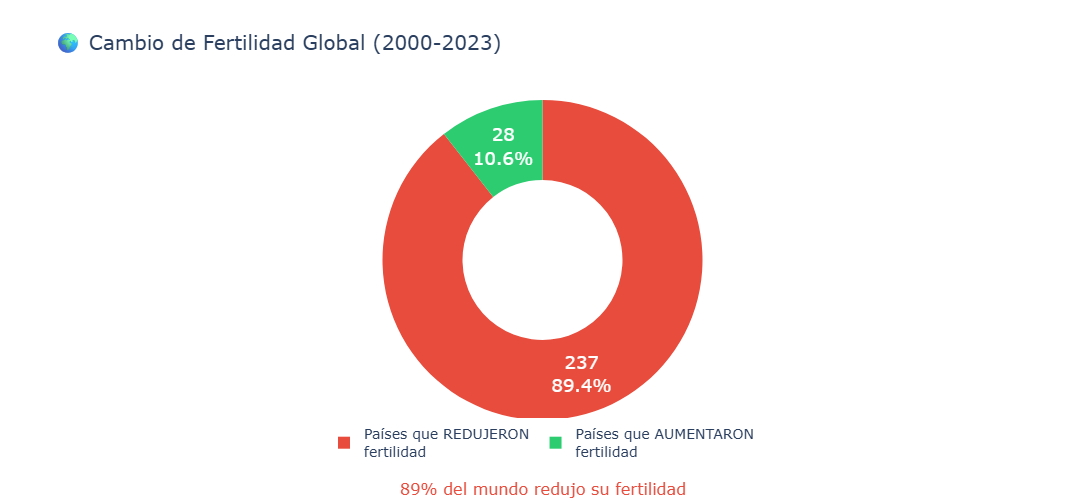

In [33]:
import plotly.graph_objects as go

# Datos
cayeron = 237
subieron = 28
total = cayeron + subieron

# Crear gráfico de dona
fig = go.Figure(data=[go.Pie(
    labels=['Países que REDUJERON<br>fertilidad', 'Países que AUMENTARON<br>fertilidad'],
    values=[cayeron, subieron],
    hole=0.5,  # Hace el efecto "donut"
    marker=dict(colors=['#e74c3c', '#2ecc71']),
    textinfo='percent+value',
    textfont=dict(size=18, color='white'),
    hovertemplate='<b>%{label}</b><br>%{value} países (%{percent})<extra></extra>'
)])

# Agregar texto en el centro
fig.add_annotation(
    text=f'<b>{total}</b><br>países',
    x=0.5, y=0.5,
    font=dict(size=24, color='#2c3e50'),
    showarrow=False
)

fig.update_layout(
    title={
        'text': '🌍 Cambio de Fertilidad Global (2000-2023)',
        'font': {'size': 20}
    },
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    height=500,
    annotations=[
        dict(
            text='89% del mundo redujo su fertilidad',
            xref='paper', yref='paper',
            x=0.5, y=-0.25,
            showarrow=False,
            font=dict(size=16, color='#e74c3c')
        )
    ]
)

fig.show()


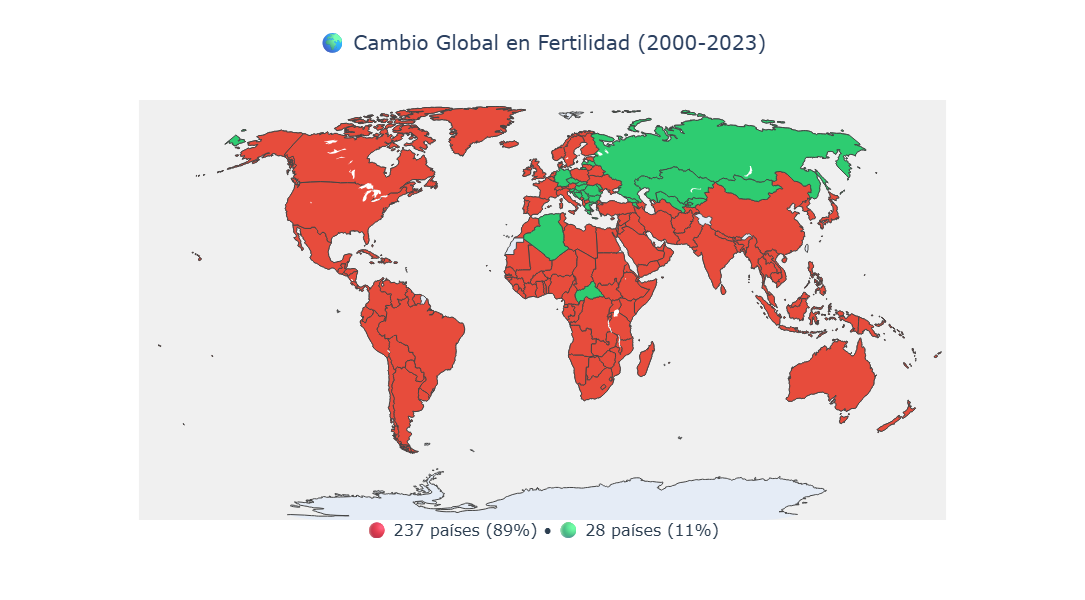


📊 ESTADÍSTICAS:
🔴 Disminuyeron: 237 países (89.4%)
🟢 Aumentaron: 28 países (10.6%)


In [34]:
import plotly.graph_objects as go

# Separar países que cayeron vs subieron
paises_cayeron = cambios[cambios['cambio_absoluto'] < 0]
paises_subieron = cambios[cambios['cambio_absoluto'] > 0]

fig = go.Figure()

# Países que CAYERON (rojo)
fig.add_trace(go.Choropleth(
    locations=paises_cayeron['country'],
    locationmode='ISO-3',
    z=[1]*len(paises_cayeron),  # Todos mismo color
    colorscale=[[0, '#e74c3c'], [1, '#e74c3c']],
    showscale=False,
    name='Disminuyó',
    hovertemplate='<b>%{location}</b><br>Fertilidad DISMINUYÓ<extra></extra>'
))

# Países que SUBIERON (verde)
fig.add_trace(go.Choropleth(
    locations=paises_subieron['country'],
    locationmode='ISO-3',
    z=[2]*len(paises_subieron),
    colorscale=[[0, '#2ecc71'], [1, '#2ecc71']],
    showscale=False,
    name='Aumentó',
    hovertemplate='<b>%{location}</b><br>Fertilidad AUMENTÓ<extra></extra>'
))

fig.update_layout(
    title={
        'text': '🌍 Cambio Global en Fertilidad (2000-2023)',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#f0f0f0'
    ),
    height=600,
    annotations=[
        dict(
            text=f'🔴 {len(paises_cayeron)} países (89%) • 🟢 {len(paises_subieron)} países (11%)',
            xref='paper',
            yref='paper',
            x=0.5,
            y=-0.05,
            showarrow=False,
            font=dict(size=16, color='#2c3e50')
        )
    ]
)

fig.show()

print(f"\n📊 ESTADÍSTICAS:")
print(f"🔴 Disminuyeron: {len(paises_cayeron)} países ({len(paises_cayeron)/len(cambios)*100:.1f}%)")
print(f"🟢 Aumentaron: {len(paises_subieron)} países ({len(paises_subieron)/len(cambios)*100:.1f}%)")

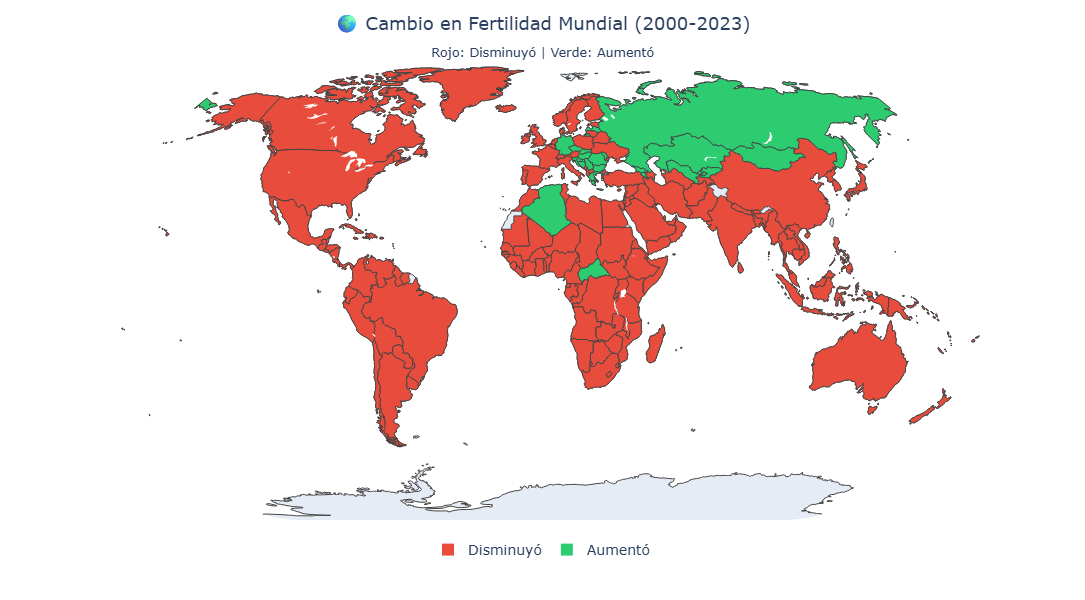


📊 RESUMEN:
Total países: 265
🔴 Disminuyeron: 237 (89.4%)
🟢 Aumentaron: 28 (10.6%)


In [36]:
import plotly.express as px
import pandas as pd

# Usar los datos de cambios que ya calculamos
# (del análisis de mayor caída que hicimos antes)

# Si no lo tienes, calculamos de nuevo:
data_2000 = master[master['year'] == 2000][['country', 'fertility']].rename(columns={'fertility': 'fert_2000'})
data_2023 = master[master['year'] == 2023][['country', 'fertility']].rename(columns={'fertility': 'fert_2023'})

cambios = data_2000.merge(data_2023, on='country')
cambios = cambios.dropna()
cambios['cambio_absoluto'] = cambios['fert_2023'] - cambios['fert_2000']
cambios['cambio_porcentual'] = ((cambios['fert_2023'] - cambios['fert_2000']) / cambios['fert_2000']) * 100

# Clasificar países
cambios['categoria'] = cambios['cambio_absoluto'].apply(
    lambda x: 'Aumentó' if x > 0 else 'Disminuyó' if x < 0 else 'Sin cambio'
)

# Mapa coroplético
fig = px.choropleth(
    cambios,
    locations='country',
    locationmode='ISO-3',
    color='categoria',
    color_discrete_map={
        'Disminuyó': '#e74c3c',    # Rojo
        'Aumentó': '#2ecc71',       # Verde
        'Sin cambio': '#95a5a6'     # Gris
    },
    hover_name='country',
    hover_data={
        'country': False,
        'fert_2000': ':.2f',
        'fert_2023': ':.2f',
        'cambio_absoluto': ':.2f',
        'categoria': True
    },
    labels={
        'fert_2000': 'Fertilidad 2000',
        'fert_2023': 'Fertilidad 2023',
        'cambio_absoluto': 'Cambio',
        'categoria': 'Tendencia'
    }
)

fig.update_layout(
    title={
        'text': '🌍 Cambio en Fertilidad Mundial (2000-2023)<br><sub>Rojo: Disminuyó | Verde: Aumentó</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='rgba(0,0,0,0)'
    ),
    height=600,
    legend=dict(
        title='',
        orientation='h',
        yanchor='bottom',
        y=-0.1,
        xanchor='center',
        x=0.5,
        font=dict(size=14)
    )
)

fig.show()

# Mostrar estadísticas
print("\n📊 RESUMEN:")
print(f"Total países: {len(cambios)}")
print(f"🔴 Disminuyeron: {len(cambios[cambios['categoria']=='Disminuyó'])} ({len(cambios[cambios['categoria']=='Disminuyó'])/len(cambios)*100:.1f}%)")
print(f"🟢 Aumentaron: {len(cambios[cambios['categoria']=='Aumentó'])} ({len(cambios[cambios['categoria']=='Aumentó'])/len(cambios)*100:.1f}%)")